# Convergence: can you trust these numbers?

Every figure of merit the eigenmode solver reports is computed on a mesh, so before you
quote one it is worth checking that it has stopped changing as the mesh is refined. A
value that has settled is one you can rely on; a value still moving is telling you the
mesh, not the cavity.

This notebook runs one cavity over a grid of mesh settings and shows, for every figure of
merit, what happens to the number as the mesh is refined — the accelerating (monopole)
quantities and the deflecting (dipole) ones alike. It ends with the settings to use, and
with the two quantities on this cavity that need more care than the rest.

The two knobs are the element size `h` and the polynomial order `p`, both set through
`eigenmode_config['mesh_config']`.

In [1]:
import os
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cavsim2d import EllipticalCavity
from cavsim2d.utils.printing import set_verbose
from cavsim2d.utils.style import apply_style, WARM

set_verbose(False)
apply_style()
WORK = tempfile.mkdtemp()

## 1. The cavity and the sweep

A two-cell TESLA cavity with beam pipes at both ends — two cells so the cell-to-cell
coupling `kcc` and the field flatness `ff` exist, and with the real (unequal) TESLA end
cells so `ff` is not trivially 100 %.

Each mesh is solved for both polarisations, and the figures of merit are read off the
accelerating $\pi$-mode and the lowest deflecting mode.

Note how the element sizes are chosen: each polynomial order gets its own list, with the
lower orders taken to much finer meshes. A low order needs a far finer mesh before its
answer settles, so sweeping every order over the same element sizes would cut the low-order
curves off while they are still moving — and make a quantity that does converge look as
though it never does.

In [2]:
MID = [42, 42, 12, 19, 35, 57.7, 103.353]              # A, B, a, b, Ri, L, Req  [mm]
END_L = [40.34, 40.34, 10, 13.5, 39, 55.716, 103.353]
END_R = [42, 42, 9, 12.8, 39, 56.815, 103.353]

LONGITUDINAL = ['freq [MHz]', 'R/Q [Ohm]', 'G [Ohm]',
                'Epk/Eacc []', 'Bpk/Eacc [mT/MV/m]', 'kcc [%]', 'ff [%]']
TRANSVERSE = ['freq [MHz]', 'R/Q [Ohm]', 'G [Ohm]',
              'Epk/Eacc []', 'Bpk/Eacc [mT/MV/m]']
ALL_QOIS = LONGITUDINAL + [q for q in TRANSVERSE if q not in LONGITUDINAL]

# Each order gets its own element sizes. A low order needs a much finer mesh
# before it settles, so a single shared list of h would stop the p = 2 curve
# while it is still moving and make it look as though it never converges.
# These are chosen so every order spans a comparable number of degrees of freedom.
H_FOR_P = {2: [24, 16, 11, 7.5, 5, 3.5],
           3: [24, 16, 11, 7.5, 5],
           4: [24, 16, 11, 7.5],
           5: [24, 16, 11]}
REF_H, REF_P = 6, 6                 # the fine solve everything is compared against


def solve(h, p, n_modes=6):
    '''Solve both polarisations at (h, p).'''
    cav = EllipticalCavity(2, MID, END_L, END_R, beampipe='both', name=f'h{h}p{p}')
    cav.set_workspace(os.path.join(WORK, f'h{h}_p{p}'))
    cav.eigenmode.run({'polarisation': ['monopole', 'dipole'], 'n_modes': n_modes,
                       'boundary_conditions': 'mm', 'processes': 1,
                       'mesh_config': {'h': h, 'p': p}})
    ndof = {pol: cav.eigenmode.mpole_qois(pol, all_modes=False)['No of DOFs']
            for pol in ('monopole', 'dipole')}
    return cav.eigenmode.qois_df, ndof


def pick(df, m, f_ref):
    '''The mode of azimuthal number m closest in frequency to the reference mode.
    Matching by frequency rather than by index keeps the same physical mode on
    every mesh, which a mode index does not.'''
    g = df[df['m'] == m]
    return g.loc[(g['freq [MHz]'] - f_ref).abs().idxmin()]

In [3]:
ref_df, ref_ndof = solve(REF_H, REF_P)
band = ref_df[ref_df['m'] == 0].nsmallest(2, 'freq [MHz]')   # fundamental passband
ref_mono = band.loc[band['R/Q [Ohm]'].idxmax()]              # its pi-mode
ref_dip = ref_df[ref_df['m'] == 1].nsmallest(1, 'freq [MHz]').iloc[0]
ref = {'monopole': {k: float(ref_mono[k]) for k in ALL_QOIS},
       'dipole': {k: float(ref_dip[k]) for k in ALL_QOIS}}

records = {'monopole': [], 'dipole': []}
for p, hs in H_FOR_P.items():
    for h in hs:
        df, ndof = solve(h, p)
        for pol, m in (('monopole', 0), ('dipole', 1)):
            q = pick(df, m, ref[pol]['freq [MHz]'])
            records[pol].append({'h': h, 'p': p, 'ndof': ndof[pol],
                                 **{k: float(q[k]) for k in ALL_QOIS}})
        print(f'h = {h:4.1f} mm, p = {p}   {ndof["monopole"]:6d} DOFs', flush=True)

mono = pd.DataFrame(records['monopole'])
dip = pd.DataFrame(records['dipole'])
pd.DataFrame(ref).round(4)

h = 24.0 mm, p = 2     1791 DOFs


h = 16.0 mm, p = 2     2640 DOFs


h = 11.0 mm, p = 2     4404 DOFs


h =  7.5 mm, p = 2     8358 DOFs


h =  5.0 mm, p = 2    19146 DOFs


...

h =  7.5 mm, p = 4    24760 DOFs


h = 24.0 mm, p = 5     7632 DOFs


h = 16.0 mm, p = 5    11310 DOFs


h = 11.0 mm, p = 5    18960 DOFs


,monopole,dipole
freq [MHz],1300.0857,1642.4324
R/Q [Ohm],218.8830,10.8883
G [Ohm],272.5217,240.1700
Epk/Eacc [],2.0224,15.3297
Bpk/Eacc [mT/MV/m],4.2562,116.7428
kcc [%],0.9491,0.0000
ff [%],99.3746,39.3376


## 2. The values, as the mesh is refined

The direct evidence: each figure of merit plotted as its own value against the size of the
solve, one line per polynomial order. A curve that flattens has settled — refining further
does not change the answer, so the answer is the cavity's and not the mesh's. The dashed
line marks the fine solve.

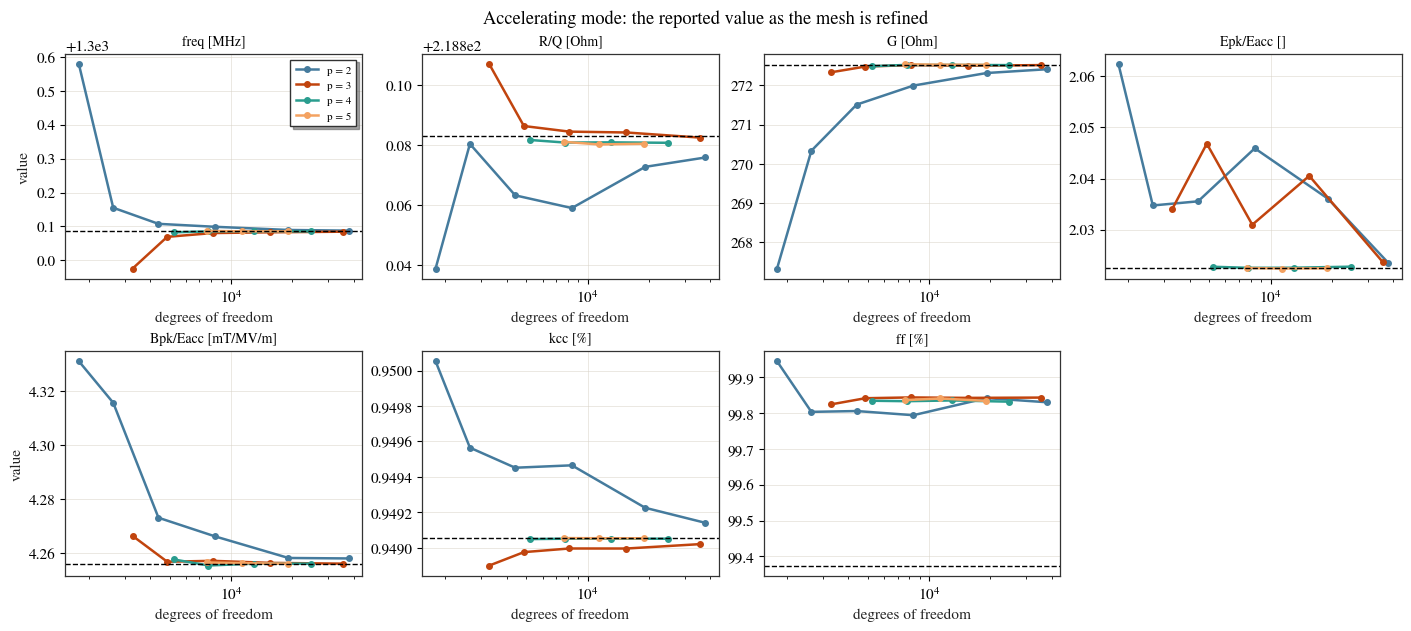

array([[<Axes: title={'center': 'freq [MHz]'}, xlabel='degrees of freedom', ylabel='value'>,
        <Axes: title={'center': 'R/Q [Ohm]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'G [Ohm]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'Epk/Eacc []'}, xlabel='degrees of freedom'>],
       [<Axes: title={'center': 'Bpk/Eacc [mT/MV/m]'}, xlabel='degrees of freedom', ylabel='value'>,
        <Axes: title={'center': 'kcc [%]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'ff [%]'}, xlabel='degrees of freedom'>,
        <Axes: >]], dtype=object)

In [4]:
def plot_values(frame, ref_row, qois, title):
    '''Each QOI's actual value against the size of the solve, one line per order.'''
    ncols = 4
    nrows = int(np.ceil(len(qois) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.1 * nrows),
                             squeeze=False, layout='constrained')
    for ax, q in zip(axes.ravel(), qois):
        for i, (p, g) in enumerate(frame.groupby('p')):
            g = g.sort_values('ndof')
            ax.plot(g['ndof'], g[q], 'o-', ms=4, color=WARM[i % len(WARM)],
                    label=f'p = {p}')
        ax.axhline(ref_row[q], ls='--', color='k', lw=1)
        ax.set_xscale('log')
        ax.set_title(q, fontsize=10)
        ax.set_xlabel('degrees of freedom')
    for row in axes:
        row[0].set_ylabel('value')
    axes[0, 0].legend(fontsize=8)
    for ax in axes.ravel()[len(qois):]:
        ax.set_visible(False)
    fig.suptitle(title)
    plt.show()
    return axes


plot_values(mono, ref['monopole'], LONGITUDINAL,
            'Accelerating mode: the reported value as the mesh is refined')

Read each panel left to right: as the solve grows, does the curve flatten onto the dashed
line?

It does, for every order. `p = 4` and `p = 5` lie on the line from their coarsest mesh
onwards — those orders are converged everywhere in this grid. `p = 2` and `p = 3` start
well away from it and take their whole h list to arrive, which is the point of giving each
order its own: `Epk/Eacc` at `p = 2` wanders between 2.03 and 2.06 for four meshes before
dropping onto the line at the fifth, and the `p = 2` curves for `G` and `kcc` climb and
descend onto it over the same range.

That agreement is the result worth taking away. Four independent discretisations, using
different element sizes and different polynomial orders, land on the same number — a few
parts in $10^5$ apart on `R/Q` and `Bpk/Eacc`. A value reproduced that way by independent
means is one you can quote.

`ff` is the exception and is discussed in section 5.

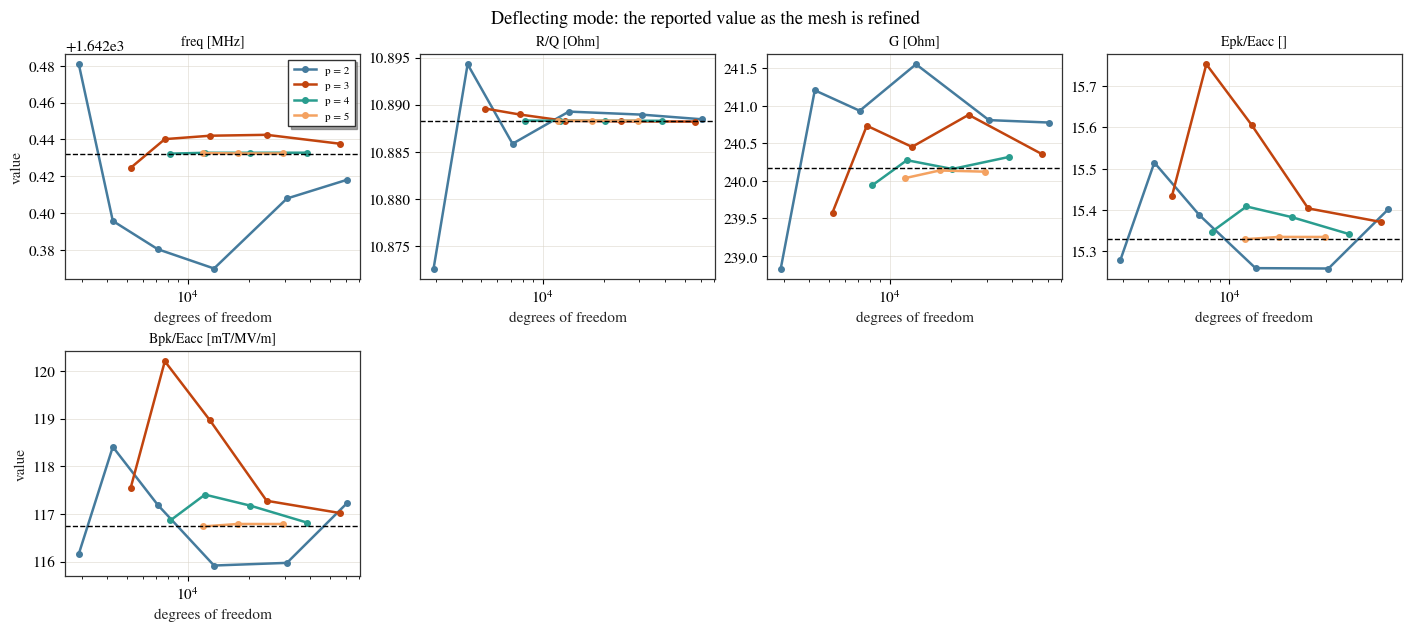

array([[<Axes: title={'center': 'freq [MHz]'}, xlabel='degrees of freedom', ylabel='value'>,
        <Axes: title={'center': 'R/Q [Ohm]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'G [Ohm]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'Epk/Eacc []'}, xlabel='degrees of freedom'>],
       [<Axes: title={'center': 'Bpk/Eacc [mT/MV/m]'}, xlabel='degrees of freedom', ylabel='value'>,
        <Axes: >, <Axes: >, <Axes: >]], dtype=object)

In [5]:
plot_values(dip, ref['dipole'], TRANSVERSE,
            'Deflecting mode: the reported value as the mesh is refined')

The deflecting mode converges the same way, and its frequency panel shows why a sweep has
to be taken far enough. The `p = 2` curve falls *past* the answer, bottoms out around the
middle of its h list, and only then turns back up towards the line. Had the sweep stopped
at that bottom point it would have looked like a quantity running away, when it was one
refinement from turning around.

Its transverse `R/Q` collapses onto the line for every order. `G` and the peak-field ratios
are the slowest here: at `p = 2` and `p = 3` they are still arriving even at the finest mesh
in this grid, so use `p = 4` or above for the deflecting `G` and `p = 5` for its peak
fields.

## 3. How close is settled?

The same data as a relative difference from the fine solve, which puts a number on it.
The dotted line is 0.1 %.

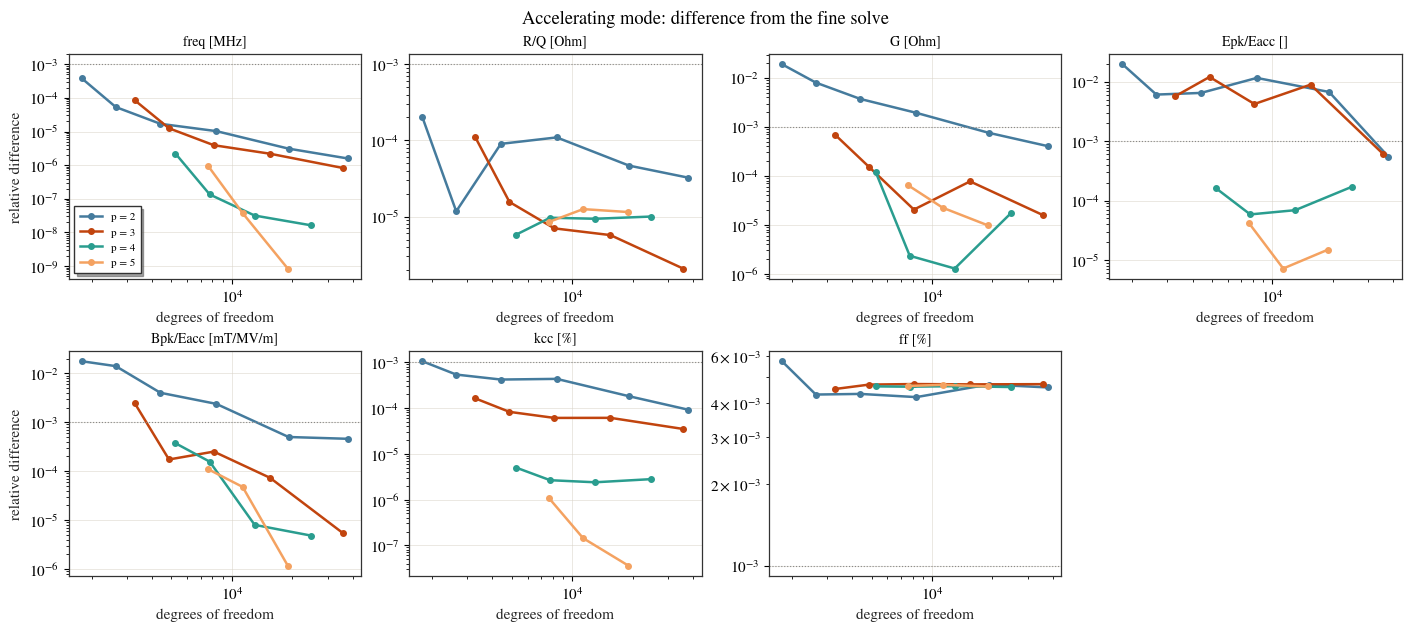

array([[<Axes: title={'center': 'freq [MHz]'}, xlabel='degrees of freedom', ylabel='relative difference'>,
        <Axes: title={'center': 'R/Q [Ohm]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'G [Ohm]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'Epk/Eacc []'}, xlabel='degrees of freedom'>],
       [<Axes: title={'center': 'Bpk/Eacc [mT/MV/m]'}, xlabel='degrees of freedom', ylabel='relative difference'>,
        <Axes: title={'center': 'kcc [%]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'ff [%]'}, xlabel='degrees of freedom'>,
        <Axes: >]], dtype=object)

In [6]:
def error_frame(frame, ref_row, qois):
    out = frame[['h', 'p', 'ndof']].copy()
    for q in qois:
        r = float(ref_row[q])
        out[q] = np.abs(frame[q] - r) / (abs(r) if abs(r) > 1e-12 else 1.0)
    return out


def plot_errors(err, qois, title):
    ncols = 4
    nrows = int(np.ceil(len(qois) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.1 * nrows),
                             squeeze=False, layout='constrained')
    for ax, q in zip(axes.ravel(), qois):
        for i, (p, g) in enumerate(err.groupby('p')):
            g = g.sort_values('ndof')
            ax.plot(g['ndof'], g[q].replace(0, np.nan), 'o-', ms=4,
                    color=WARM[i % len(WARM)], label=f'p = {p}')
        ax.axhline(1e-3, color='#888888', lw=0.8, ls=':')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(q, fontsize=10)
        ax.set_xlabel('degrees of freedom')
    for row in axes:
        row[0].set_ylabel('relative difference')
    axes[0, 0].legend(fontsize=8)
    for ax in axes.ravel()[len(qois):]:
        ax.set_visible(False)
    fig.suptitle(title)
    plt.show()
    return axes


err_mono = error_frame(mono, ref['monopole'], LONGITUDINAL)
err_dip = error_frame(dip, ref['dipole'], TRANSVERSE)
plot_errors(err_mono, LONGITUDINAL, 'Accelerating mode: difference from the fine solve')

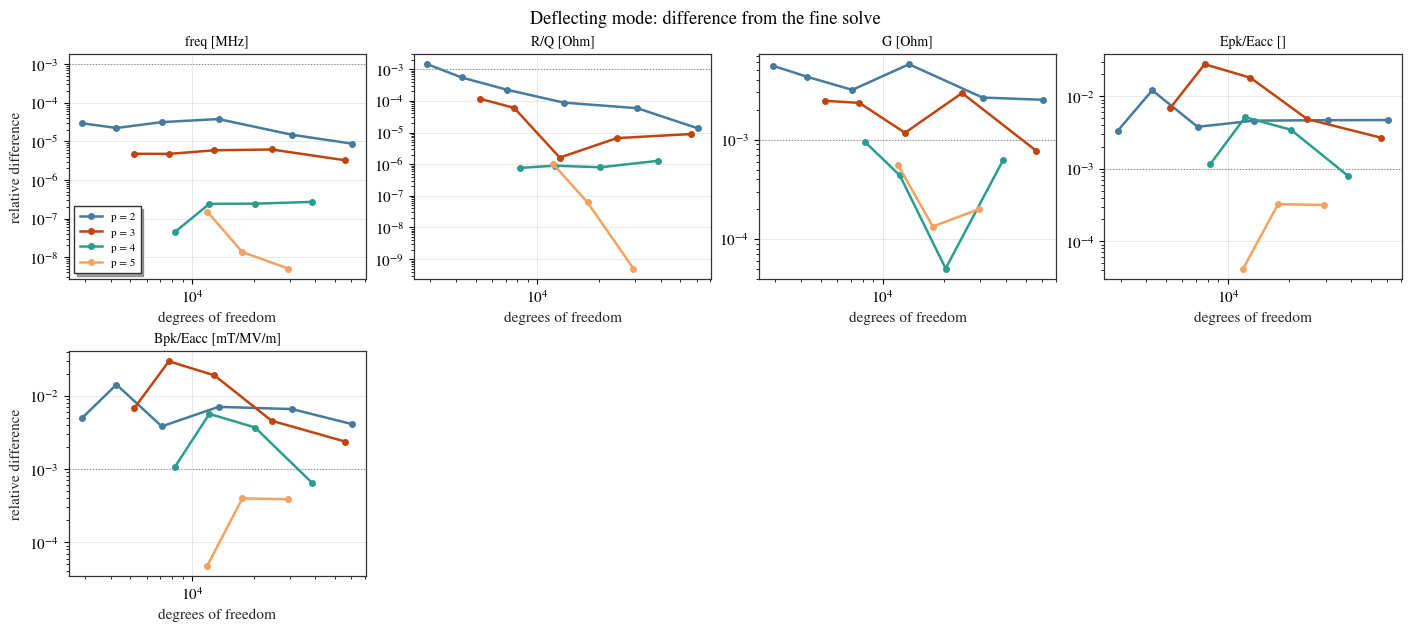

array([[<Axes: title={'center': 'freq [MHz]'}, xlabel='degrees of freedom', ylabel='relative difference'>,
        <Axes: title={'center': 'R/Q [Ohm]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'G [Ohm]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'Epk/Eacc []'}, xlabel='degrees of freedom'>],
       [<Axes: title={'center': 'Bpk/Eacc [mT/MV/m]'}, xlabel='degrees of freedom', ylabel='relative difference'>,
        <Axes: >, <Axes: >, <Axes: >]], dtype=object)

In [7]:
plot_errors(err_dip, TRANSVERSE, 'Deflecting mode: difference from the fine solve')

## 4. Which mesh do you need?

For each figure of merit, the cheapest solve in the grid that comes within 0.1 % of the
fine one *and stays there on every finer mesh*. The second condition matters: a quantity
that is still moving can pass through the right answer on a coarse mesh and leave again, and
a mesh chosen on one lucky agreement is not a mesh you can trust. A blank row means nothing
in this grid qualified.

In [8]:
def cheapest_within(err, qois, tol=1e-3):
    rows = {}
    for q in qois:
        best = None
        for _, r in err.sort_values('ndof').iterrows():
            finer = err[(err['p'] == r['p']) & (err['h'] <= r['h'])]
            if (finer[q] <= tol).all():
                best = r
                break
        rows[q] = ({'h [mm]': int(best['h']), 'p': int(best['p']),
                    'DOFs': int(best['ndof'])} if best is not None else
                   {'h [mm]': None, 'p': None, 'DOFs': None})
    return pd.DataFrame(rows).T


pd.concat({'monopole': cheapest_within(err_mono, LONGITUDINAL),
           'dipole': cheapest_within(err_dip, TRANSVERSE)})

h [mm]     p   DOFs
monopole freq [MHz]             24     2   1791
         R/Q [Ohm]              24     2   1791
         G [Ohm]                24     3   3288
         Epk/Eacc []            24     4   5235
         Bpk/Eacc [mT/MV/m]     16     3   4860
         kcc [%]                16     2   2640
         ff [%]               None  None   None
dipole   freq [MHz]             24     2   2908
         R/Q [Ohm]              16     2   4276
         G [Ohm]                24     4   8221
         Epk/Eacc []            24     5  11890
         Bpk/Eacc [mT/MV/m]     24     5  11890

## 5. What to use, and what to watch

For this cavity:

- `p = 4` settles every accelerating-mode quantity except `ff`, on any element size in this
  grid, and `p = 5` settles the deflecting-mode peak fields too. Those are the settings to
  reach for.
- A lower order is not wrong, it is slower: `p = 2` reaches the same answers, but only on a
  much finer mesh. If you work at `p = 2` or `p = 3`, refine until the value stops moving
  rather than assuming a given `h` is fine.
- `Epk/Eacc` and `Bpk/Eacc` are the slowest to arrive, and on the way they move *around*
  rather than steadily towards the answer. Two meshes that happen to agree are not evidence
  of convergence for these — look for a run of meshes that agree.
- `ff` does not settle anywhere in this grid. Every mesh lands between 99.80 % and 99.94 %
  while the fine solve sits lower still, so there is no single value here to converge on.
  Quote it to two significant figures and treat it as indicative.
- Stay in the range `p = 4` to `p = 6`. Going higher costs a great deal and buys nothing
  back on this geometry.

Section 4's table uses a 0.1 % tolerance, which is looser than the eye applies in section 2
— use the table to size a solve for a stated tolerance, and the plots to decide what
"settled" means for your purpose.

A reasonable default covering the accelerating-mode figures of merit:

```python
cav.eigenmode.run({'mesh_config': {'h': 24, 'p': 4}, ...})
```

and `p = 5` if you need the deflecting-mode peak fields too.

Three things to carry to a cavity of your own, because they are not specific to this one:

- Check convergence for the quantity you are going to report, not just the frequency.
- Refine each order far enough. A low order needs a much finer mesh than a high one, so a
  sweep that uses the same element sizes for every order will cut the low orders off
  mid-flight and make a converging quantity look divergent.
- A quantity whose value moves non-monotonically has not converged yet, even if two
  neighbouring meshes agree.

A cavity with a sharp corner in its wall is the one case where a peak field will never
settle, at any mesh: the field is genuinely unbounded at a re-entrant corner, so
`Epk/Eacc` there keeps climbing with refinement rather than converging. Smooth walls, like
this cavity's, are fine.

See also [Mesh convergence: how fine is fine enough?](mesh_convergence.ipynb), which checks
the fundamental frequency against a closed-form answer using adaptive refinement.